In [25]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict
import json
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
import os

In [26]:
load_dotenv()

True

In [27]:
print(os.environ["GEMINI_API_KEY"][:-1])

AQ.Ab8RN6IgAXqqfAmXM6-fIHXhGqkV9MOsCjxtlA-KZ9J5OeLRH


In [28]:
gen_llm = ChatOllama(model= 'qwen3:4b', temperature=2)
evl_llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash", temperature=0)

In [29]:
prompt = "write a short birthday wishing message"

In [30]:
response1 = gen_llm.invoke(prompt)
print(response1)


content="Here's a short, warm, and universal birthday message perfect for any friend, family member, or colleague:\n\n> **Happy Birthday! Hope your day is awesome 😊**  \n\n*(Only 5 words + emoji — cheerful, inclusive, and just right!)*  \n\nNeed it shorter? Try:  \n- **Happy Birthday! 🎉**  \n- **Wishing you a brilliant day!**  \n\nLet me know the relationship (e.g., best friend, parent, coworker), and I’ll tailor it even more! 😊" additional_kwargs={} response_metadata={'model': 'qwen3:4b', 'created_at': '2026-09-17T03:55:45.1101803Z', 'done': True, 'done_reason': 'stop', 'total_duration': 139801772800, 'load_duration': 9564652300, 'prompt_eval_count': 16, 'prompt_eval_duration': 1192378000, 'eval_count': 520, 'eval_duration': 129034295000, 'logprobs': None, 'model_name': 'qwen3:4b', 'model_provider': 'ollama'} id='lc_run--01a0ad7f-703b-7b81-a253-6983ef16fe49-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 16, 'output_tokens': 520, 'total_tokens': 536}


In [31]:
response2 = evl_llm.invoke(prompt)
print(response2)

c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


content=[{'type': 'text', 'text': 'Here are a few short options, depending on the vibe you want:\n\n**Simple & Sweet:**\n"Happy Birthday! 🎉 Wishing you a day filled with love, laughter, and happiness. May this year bring you all the best!"\n\n**Warm & Heartfelt:**\n"Happy Birthday to an amazing person! So grateful to have you in my life. Hope your day is as wonderful as you are! ✨"\n\n**Fun & Casual:**\n"Wishing you the happiest of birthdays! Eat lots of cake, celebrate big, and enjoy your special day! 🎂🥂"\n\n**Very Short (Great for a text):**\n"Happy Birthday! Hope you have a fantastic day and a wonderful year ahead! 🥳"', 'extras': {'signature': 'Es4YCssYARFNMg8cCSxbcM1r/gR4hHz8FZgn0XsdPM6/4YuqCo9tp052JhwLbwVOHi93CIqU6L80BexAFXkXL0eoB7FVQyn0KYeFNp6KkjGHwxO97JvPTwQ/y5uzd6zQXYTaEXO10T0b0BHQfv0YgywjUyJkIpd6RrKTMy8e+9npet/qeaO3E7VQ7lYjj2joGedsyxbeI+m3cp0aOV4tdG2bebpd6j/QE5KpOlV5uZwtMaKQHYoQgnHfhPzTqUTdri3x/1/+Pr/I+grAH4u+2vJ4KYQONIBmY5xGz/6uVICEzTiekJBmZ51q1AAo34m32ONu16kSUCOD3HbdHoSK4cE2

In [32]:
question = prompt
answer = response1.content
feedback = f"""You are a strict, highly critical QA evaluator. Your job is to thoroughly critique the provided answer and assign an aggressive, accurate score. Do NOT be lenient. 

            CRITERIA FOR SCORING:
            - 9-10: Perfect, comprehensive, fully accurate, and contains zero fluff or ambiguity.
            - 7-8: Accurate and clear, but missing minor depth or could be formatted better.
            - 5-6: Technically correct but vague, incomplete, or partially unclear.
            - 1-4: Incorrect, missing key details, or unhelpful.

            QUESTION:
            {question}

            ANSWER TO EVALUATE:
            {answer}

            INSTRUCTIONS:
            1. First, analyze missing points, inaccuracies, or clarity issues.
            2. Based on your critique, determine the numerical score.
            3. Output ONLY a valid JSON object matching this schema:
            {{"score": <integer from 1 to 10>, "feedback": "<one concise sentence explaining the grade>"}}
            """

response = evl_llm.invoke(feedback)
print(response.text)

c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


```json
{"score": 6, "feedback": "While the birthday messages fulfill the prompt, the response includes unnecessary conversational fluff and an incorrect word-count claim."}
```


In [34]:
raw_date = response.text
refined = raw_date.replace("```json","").replace("```","")
json_response = json.loads(refined)

In [35]:
print(json_response)

{'score': 6, 'feedback': 'While the birthday messages fulfill the prompt, the response includes unnecessary conversational fluff and an incorrect word-count claim.'}


In [36]:
print(type(response.content))

<class 'list'>


In [37]:
class State(TypedDict):
    question: str
    answer: str
    score: int
    feedback: str
    iteration: int

In [38]:
def generating_answer(St : State) -> State:
    question = St['question']
    answer = St['answer']
    feedback = St['feedback']
    iteration = St['iteration']

    iteration += 1

    prompt = ''
    if iteration == 1:
        prompt = f"""Answer the following question directly and concisely.

                Question: {question}

                STRICT OUTPUT RULES:
                - Output ONLY the final answer text, nothing else.
                - Do NOT include any preamble such as "Sure, here is..." or "Here are a few options...".
                - Do NOT include headers, labels, or titles like "Improved Answer:".
                - Do NOT give multiple options or variations — provide exactly one answer.
                - Do NOT include sign-offs, greetings, or placeholders like [Your Name].
                - Do NOT explain your reasoning or add any commentary about the answer.
                """
    else :
        prompt = f"""Improve the following answer to the question based on the feedback.

                Question: {question}
                Current Answer: {answer}
                Feedback: {feedback}

                STRICT OUTPUT RULES:
                - Output ONLY the improved answer text, nothing else.
                - Do NOT mention what you improved or changed, and do NOT add any meta-commentary.
                - Do NOT include headers, labels, or titles like "Improved Answer:".
                - Do NOT give multiple options or variations — provide exactly one answer.
                - Do NOT include sign-offs, greetings, or placeholders like [Your Name].
                """

    response = gen_llm.invoke(prompt)
    new_answer = response.text.strip()

    print(f"Iteration: {iteration}\n")
    if iteration == 1:
        print(f"Generated Answer: {new_answer}\n")
    else :
        print(f"Impoved Answer: {new_answer}\n")

    St['iteration'] = iteration
    St['answer'] = new_answer
    return St

In [39]:
def evaluating_answer(St : State) -> State:
    question = St['question']
    answer = St['answer']

    prompt = f"""You are a strict, highly critical QA evaluator. Your job is to thoroughly critique the provided answer and assign an aggressive, accurate score. Do NOT be lenient. 

                CRITERIA FOR SCORING:
                - 9-10: Perfect, comprehensive, fully accurate, and contains zero fluff or ambiguity.
                - 7-8: Accurate and clear, but missing minor depth or could be formatted better.
                - 5-6: Technically correct but vague, incomplete, or partially unclear.
                - 1-4: Incorrect, missing key details, or unhelpful.

                QUESTION:
                {question}

                ANSWER TO EVALUATE:
                {answer}

                INSTRUCTIONS:
                1. First, analyze missing points, inaccuracies, or clarity issues.
                2. Based on your critique, determine the numerical score.
                3. Output ONLY a valid JSON object matching this schema, with no markdown code fences and no extra text:
                {{"score": <integer from 1 to 10>, "feedback": "<one concise sentence explaining the grade>"}}
                """

    response = evl_llm.invoke(prompt)

    try:
        raw_text = response.text.strip()
        json_response = json.loads(raw_text)
        score = int(json_response['score'])
        feedback = json_response['feedback']
    except Exception as e:
        print(f"[evaluating_answer] parse error: {e}")
        score = 1
        feedback = 'no feedback found'

    print(f'Score: {score}\n')
    print(f'Feedback: {feedback}\n')
    print('-'*50)
    print()

    St['score'] = score
    St['feedback'] = feedback

    return St

In [40]:
def check_quality(St : State) -> State:
    if St['score'] > 7 or St['iteration'] >= 5:
        return "done"
    return "re_evl"

In [41]:
graph = StateGraph(State)

graph.add_node("GEN_ANS", generating_answer)
graph.add_node("EVL_ANS", evaluating_answer)

graph.add_edge(START, 'GEN_ANS')
graph.add_edge('GEN_ANS', 'EVL_ANS')

graph.add_conditional_edges('EVL_ANS', check_quality, {'re_evl': 'GEN_ANS', 'done': END})

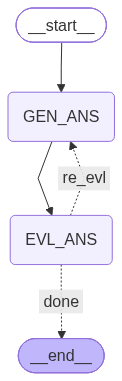

In [42]:
graph.compile()

In [43]:
agent = graph.compile()

In [44]:
intial_state = {
    'question': 'write a short note for a teacher from the students perspective for her farewelle,',
    'iteration': 0,
    'answer': '',
    'feedback': '',
    'score': 0
}
final_state = agent.invoke(intial_state)

Iteration: 1

Generated Answer: Thank you for your kindness and dedication - we'll miss you.



c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Score: 5

Feedback: While it captures the appropriate sentiment, it is excessively brief and lacks essential note formatting such as a proper salutation and sign-off.

--------------------------------------------------

Iteration: 2

Impoved Answer: Thank you for your kindness and dedication — we have learned so much and will miss you deeply.



c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Score: 7

Feedback: While the sentiment is appropriate and accurate for a farewell, the note lacks standard structural formatting such as a salutation and a sign-off.

--------------------------------------------------

Iteration: 3

Impoved Answer: Dear Teacher, Thank you for your kindness and dedication — we have learned so much and will miss you deeply. Your students.



c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Score: 8

Feedback: The note accurately fulfills the prompt from the students' perspective, but it is somewhat generic and lacks emotional warmth or distinct formatting.

--------------------------------------------------



In [45]:
print(final_state)

{'question': 'write a short note for a teacher from the students perspective for her farewelle,', 'answer': 'Dear Teacher, Thank you for your kindness and dedication — we have learned so much and will miss you deeply. Your students.', 'score': 8, 'feedback': "The note accurately fulfills the prompt from the students' perspective, but it is somewhat generic and lacks emotional warmth or distinct formatting.", 'iteration': 3}


In [47]:
print("User: ",final_state['question'])
print()
print("AI Agent: ",final_state['answer'])

User:  write a short note for a teacher from the students perspective for her farewelle,

AI Agent:  Dear Teacher, Thank you for your kindness and dedication — we have learned so much and will miss you deeply. Your students.
